In [8]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

#### Input

In [9]:
basedir = '/home/erwin/data/ismip7/AIS/'
model = 'CESM2-WACCM'
domain = 'SDBN1-8000m'
version = 'v2'
scenario = 'ssp585'

sec_per_year = 31556943.36
freshwater_density = 1000.0

#### SMB anomaly

In [10]:
#Historical
path = os.path.join(basedir,model,'historical',domain,'acabf-anomaly',version,'*')
ds = xr.open_mfdataset(path)
ds = ds.sel(time=slice('1995-01-01', '2025-01-01'))

#Future bit
path = os.path.join(basedir,model,scenario,domain,'acabf-anomaly',version,'*20*.nc')
ds2 = xr.open_mfdataset(path)
ds2 = ds2.sel(time=slice('1995-01-01', '2025-01-01'))

# Paste the two together
dds = xr.merge([ds,ds2])

# Take a time-mean
weights = dds.time.dt.daysinmonth
dds_mean = (dds * weights).sum(dim='time') / weights.sum()
dds_mean = dds_mean.rename({'acabf-anomaly':'SMB'})

# Convert to m.w.e. / yr
dds_mean.SMB[:] = dds_mean.SMB[:] * sec_per_year / freshwater_density

# Save to netcdf
dds_mean.to_netcdf(f'/home/erwin/data/ismip7/AIS/{model}/SMB_offset_{model}_{scenario}.nc')

/tmp/ipykernel_19357/3592794602.py:12: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  dds = xr.merge([ds,ds2])
/tmp/ipykernel_19357/3592794602.py:12: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  dds = xr.merge([ds,ds2])


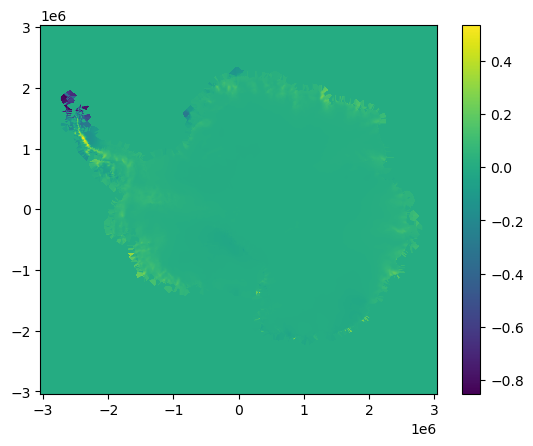

In [12]:
plt.pcolormesh(dds_mean.x,dds_mean.y,dds_mean.SMB)
plt.colorbar()